### IMPORTS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from mlxtend.regressor import StackingCVRegressor

### LOADING DATA

In [2]:
DATA = pd.read_csv('nyc_taxi_trip_duration.csv')

In [3]:
DATA.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


### MISSING VALUES

In [4]:
DATA.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

### ONE HOT ENCODING

#### STORE AND FORWARD FLAG

In [5]:
DATA = pd.concat([pd.get_dummies(DATA['store_and_fwd_flag']), DATA], axis = 1)

In [6]:
DATA = DATA.drop(['store_and_fwd_flag'], axis = 1)

#### VENDOR ID

In [7]:
DATA = pd.concat([pd.get_dummies(DATA['vendor_id'], prefix = 'vendor'), DATA], axis = 1)

In [8]:
DATA = DATA.drop(['vendor_id'], axis = 1)

In [9]:
DATA.head()

,vendor_1,vendor_2,N,Y,id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
0,0,1,1,0,id1080784,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,400
1,1,0,1,0,id0889885,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,1100
2,0,1,1,0,id0857912,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,1635
3,0,1,1,0,id3744273,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,1141
4,1,0,1,0,id0232939,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,848


### FEATURE ENGINEERING

#### PICKUP DATETIME

In [10]:
DATA['pickup_datetime'] = pd.to_datetime(DATA['pickup_datetime'])

In [11]:
DATA['pickup_weekday'] = DATA['pickup_datetime'].dt.weekday

In [12]:
DATA['pickup_weekofyear'] = DATA['pickup_datetime'].dt.isocalendar().week.astype('int64')

In [13]:
DATA['pickup_hour'] = DATA['pickup_datetime'].dt.hour

In [14]:
DATA['pickup_minute'] = DATA['pickup_datetime'].dt.minute

In [15]:
DATA['pickup_dt'] = (DATA['pickup_datetime'] - DATA['pickup_datetime'].min()).dt.total_seconds()

In [16]:
DATA['pickup_week_hour'] = DATA['pickup_weekday'] * 24 + DATA['pickup_hour']

In [17]:
DATA = DATA.drop(['pickup_datetime'], axis = 1)

#### DISTANCE

In [18]:
dlon = DATA["pickup_longitude"] - DATA["dropoff_longitude"]
dlat = DATA["pickup_latitude"] - DATA["dropoff_latitude"]
a = (np.sin(dlat/2))**2 + np.cos(DATA["pickup_latitude"]) * np.cos(DATA["dropoff_latitude"]) * (np.sin(dlon/2))**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
DATA["distance"] = 6373.0 * c

#### BINNING

In [19]:
DATA['pickup_latitude_round3'] = np.round(DATA['pickup_latitude'],3)
DATA['pickup_longitude_round3'] = np.round(DATA['pickup_longitude'],3)

In [20]:
DATA['dropoff_latitude_round3'] = np.round(DATA['dropoff_latitude'],3)
DATA['dropoff_longitude_round3'] = np.round(DATA['dropoff_longitude'],3)

#### TIMING DURATION

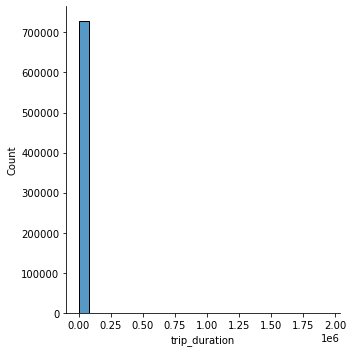

In [21]:
sns.displot(DATA['trip_duration'], kde = False, bins = 25)

##### Normalize trip duration

In [22]:
DATA['trip_duration'] = np.log1p(DATA['trip_duration'])

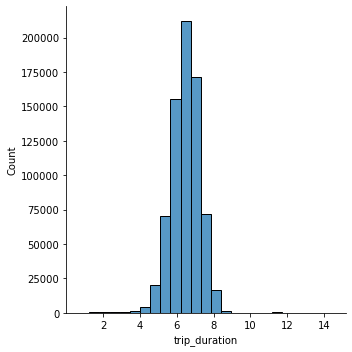

In [23]:
sns.displot(DATA['trip_duration'], kde = False, bins = 25)

In [24]:
DATA.head()

,vendor_1,vendor_2,N,Y,id,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,...,pickup_weekofyear,pickup_hour,pickup_minute,pickup_dt,pickup_week_hour,distance,pickup_latitude_round3,pickup_longitude_round3,dropoff_latitude_round3,dropoff_longitude_round3
0,0,1,1,0,id1080784,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,...,9,16,40,5157547.0,16,80.142332,40.779,-73.954,40.771,-73.964
1,1,0,1,0,id0889885,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,...,10,23,35,6132863.0,119,238.106427,40.732,-73.988,40.695,-73.995
2,0,1,1,0,id0857912,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,...,7,17,59,4471099.0,161,462.455755,40.721,-73.997,40.775,-73.948
3,0,1,1,0,id3744273,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,...,1,9,44,380597.0,33,136.827598,40.760,-73.962,40.781,-73.957
4,1,0,1,0,id0232939,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,...,7,6,42,4084869.0,54,274.888260,40.708,-74.017,40.741,-73.988


### TEST  / TRAIN SPLIT

In [25]:
X = DATA.drop(['id', 'dropoff_datetime', 'trip_duration'], axis = 1)
y = DATA['trip_duration']

### MODEL

In [26]:
def cv_score(ml_model, rstate = 11,cols = X.columns):
    i = 1
    
    kf = KFold(n_splits=5,random_state=rstate,shuffle=True)
    
    for train_index,test_index in kf.split(X[cols],y):
        
        xtr,xvl = X[cols].loc[train_index].values, X[cols].loc[test_index].values
        ytr,yvl = y[train_index].values, y[test_index].values

        model = ml_model
        model.fit(xtr, ytr)
        train_val = model.predict(xtr)
        pred_val = model.predict(xvl)
        rmse_score_train = np.sqrt(mean_squared_error(ytr, train_val))
        rmse_score = np.sqrt(mean_squared_error(yvl, pred_val))

        print('\n{} of kfold {} Train RMSE: {:.5f} Test RMSE: {:.5f}'.format(i,kf.n_splits,rmse_score_train,rmse_score))
        
        i+=1

#### RANDOM FOREST

In [27]:
rf_params = {'random_state': 0, 'n_estimators': 19, 'max_depth': 11, 'n_jobs': -1, "min_samples_split": 43}
cv_score(RandomForestRegressor(**rf_params))


1 of kfold 5 Train RMSE: 0.42022 Test RMSE: 0.43760

2 of kfold 5 Train RMSE: 0.41974 Test RMSE: 0.43824

3 of kfold 5 Train RMSE: 0.42215 Test RMSE: 0.42899

4 of kfold 5 Train RMSE: 0.42147 Test RMSE: 0.43381

5 of kfold 5 Train RMSE: 0.42163 Test RMSE: 0.43113


#### XGBOOST

In [28]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,test_size=1/3, random_state=0)

In [29]:
dtrain = xgb.DMatrix(xtrain, label=ytrain)
dvalid = xgb.DMatrix(xtest, label=ytest)

watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

In [30]:
xgb_params = {"objective": "reg:linear", 'eval_metric': "rmse", "eta": 0.05, "min_child_weight": 10, "subsample": 0.9,
              "colsample_bytree": 0.7, "max_depth": 5, 'silent': 1, "seed": 2019, "nthread": -1, "lambda": 2}

xgb_model = xgb.train(xgb_params, dtrain, 100, watchlist, early_stopping_rounds=50,maximize=False, verbose_eval=20)
print('Modeling RMSE %.5f' % xgb_model.best_score)

[23:31:43] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/objective/regression_obj.cu:170: reg:linear is now deprecated in favor of reg:squarederror.
[23:31:43] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:541: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[0]	train-rmse:5.72182	valid-rmse:5.71905
[20]	train-rmse:2.10327	valid-rmse:2.10216
[40]	train-rmse:0.86787	valid-rmse:0.86901
[60]	train-rmse:0.52074	valid-rmse:0.52454
[80]	train-rmse:0.45005	valid-rmse:0.45530
[99]	train-rmse:0.43593	valid-rmse:0.44177
Modeling RMSE 0.44177


<AxesSubplot:title={'center':'Feature importance'}, xlabel='F score', ylabel='Features'>

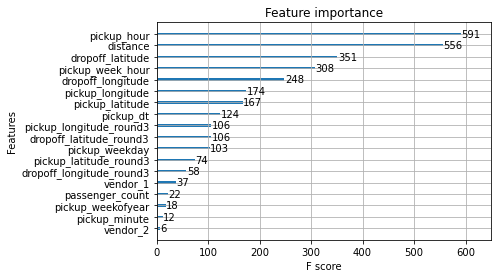

In [31]:
xgb.plot_importance(xgb_model)

In [32]:
xgb_params['num_round'] = xgb_model.best_iteration
xgb_model_final = xgb.XGBRegressor()
cv_score(xgb_model_final)


1 of kfold 5 Train RMSE: 0.38659 Test RMSE: 0.41147

2 of kfold 5 Train RMSE: 0.38607 Test RMSE: 0.41057

3 of kfold 5 Train RMSE: 0.38890 Test RMSE: 0.40254

4 of kfold 5 Train RMSE: 0.38541 Test RMSE: 0.40571

5 of kfold 5 Train RMSE: 0.38766 Test RMSE: 0.40363


#### AVERAGING

In [33]:
def cv_score_avg(ml_model_1, ml_model_2, w1 = 0.5, w2 = 0.5, cols = X.columns):
    i = 1
    
    kf = KFold(n_splits=5,random_state=11,shuffle=True)
    
    for train_index,test_index in kf.split(X[cols],y):
        
        xtr,xvl = X[cols].loc[train_index], X[cols].loc[test_index]
        ytr,yvl = y[train_index], y[test_index]

        model = ml_model_1
        ml_model_1.fit(xtr, ytr)
        pred_val_1 = ml_model_1.predict(xvl)
        
        model = ml_model_2
        ml_model_2.fit(xtr, ytr)
        pred_val_2 = ml_model_2.predict(xvl)
        
        final_pred=(pred_val_1*w1 + pred_val_2*w2)

        rmse_score = np.sqrt(mean_squared_error(yvl, final_pred))
        
        print('\n{} of kfold {} Valid RMSE: {:.5f}'.format(i,kf.n_splits,rmse_score))
        
        i+=1

In [34]:
cv_score_avg(xgb_model_final, RandomForestRegressor(**rf_params), w1 = 0.4, w2 = 0.6)


1 of kfold 5 Valid RMSE: 0.42080

2 of kfold 5 Valid RMSE: 0.42063

3 of kfold 5 Valid RMSE: 0.41196

4 of kfold 5 Valid RMSE: 0.41590

5 of kfold 5 Valid RMSE: 0.41364


#### STACKING

In [35]:
xgb_model = xgb.XGBRegressor(**xgb_params)
rf_model = RandomForestRegressor(**rf_params)
tree_model = DecisionTreeRegressor(min_samples_leaf=25, min_samples_split=25)

In [36]:
stacked_model = StackingCVRegressor(
    regressors=[xgb_model, rf_model, tree_model],
    meta_regressor=Ridge()
)

In [38]:
stacking_scores = cv_score(stacked_model)

[09:11:36] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/objective/regression_obj.cu:170: reg:linear is now deprecated in favor of reg:squarederror.
[09:11:36] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:541: 
Parameters: { num_round, silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[09:12:30] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/objective/regression_obj.cu:170: reg:linear is now deprecated in favor of reg:squarederror.
[09:12:30] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:541: 
Parameters: { num_round, silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  pass

[09:37:27] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/objective/regression_obj.cu:170: reg:linear is now deprecated in favor of reg:squarederror.
[09:37:27] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:541: 
Parameters: { num_round, silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[09:38:18] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/objective/regression_obj.cu:170: reg:linear is now deprecated in favor of reg:squarederror.
[09:38:18] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.3.0/src/learner.cc:541: 
Parameters: { num_round, silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  pass


5 of kfold 5 Train RMSE: 0.39717 Test RMSE: 0.42158
